# Topic Modeling: Descubriendo Temáticas en los Comentarios de Facebook

## Cargar el archivo
Se extrajeron 1,569 comentarios de septiembre y octubre año 2020 en los que se menciona a CitiBanamex

In [ ]:
# pip install nltk
# !pip install networkx
# import nltk
# nltk.download("stopwords")
# pip install wordcloud

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import re

import nltk
from nltk.corpus import stopwords
# nltk.download('stopwords')
from nltk.stem import SnowballStemmer

from sklearn.feature_extraction.text import CountVectorizer

import networkx as nx
# import nltkimport networkx as nx
from networkx.algorithms import community

stop_words_sp = set(stopwords.words('spanish'))
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\CESAR
[nltk_data]     QUEZADA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
df = pd.read_csv("../data/raw/BanamexFace.csv")
df.head()

,pub,usr,likes,com,fec,hor,sent,tag
0,20200805,Dayana Tinajero,18,"no inventen, acabo de llamar al call center y ...",2020-08-06,11:37:00,n,seguridad
1,20200805,Salma Madrid,5,"pesimo servicio de call center, contestan con ...",2020-08-06,12:56:00,n,atencion_call
2,20200805,Dayana Tinajero,3,"mejor voy a sucursal, ya no me da confianza na...",2020-08-06,13:20:00,n,seguridad
3,20200805,Lissy Jimenez,0,citibanamex podrían decirme dónde puedo llamar...,2020-08-06,16:04:00,o,consulta
4,20200805,Lissy Jimenez,0,citibanamex gracias si me gustaría saber cuand...,2020-08-06,16:23:00,o,consulta


### Removiendo los signos de puntuación

In [3]:
import sys
sys.path.append("../src")

from text_preprocessing import clean_text

In [4]:
# Aplicamos limpieza de texto en los comentarios
# -----------------
df['com_clean'] = df['com'].apply(clean_text)

df.head()

,pub,usr,likes,com,fec,hor,sent,tag,com_clean
0,20200805,Dayana Tinajero,18,"no inventen, acabo de llamar al call center y ...",2020-08-06,11:37:00,n,seguridad,inventen acabo llamar call center contesto chi...
1,20200805,Salma Madrid,5,"pesimo servicio de call center, contestan con ...",2020-08-06,12:56:00,n,atencion_call,pesimo servicio call center contestan voz floj...
2,20200805,Dayana Tinajero,3,"mejor voy a sucursal, ya no me da confianza na...",2020-08-06,13:20:00,n,seguridad,mejor voy sucursal da confianza personas q con...
3,20200805,Lissy Jimenez,0,citibanamex podrían decirme dónde puedo llamar...,2020-08-06,16:04:00,o,consulta,citibanamex podrían decirme dónde puedo llamar...
4,20200805,Lissy Jimenez,0,citibanamex gracias si me gustaría saber cuand...,2020-08-06,16:23:00,o,consulta,citibanamex gracias si gustaría saber vence pr...


### Estadísticos básicos de entendimiento

In [5]:
text = " ".join(df["com_clean"])
text

'inventen acabo llamar call center contesto chica casa puede ver todas cuentas da confianza ademas dia hoy llevo 18 llamadas cobranza si personal pesimo servicio call center contestan voz flojera mala gana aparte cuelgan dudas mejor voy sucursal da confianza personas q contestan estan casas informacion q debe salr banco citibanamex podrían decirme dónde puedo llamar saber termina prorroga pagar 4 meses quiero q pase fecha citibanamex gracias si gustaría saber vence programarme ningún lado dice sera q q ir sucursal tenho um problemas bloqueada tarjeta estou em esttanjero dayana tinajero ridícula sabias existe covid mucha gente hace home office vayan sacar 2 pesos quincena citibanamex urge cuenta sucursal dijeron servicio bancanet tampoco pude número telefónico correo dados alta ayudenme favor citibanamex obtengo netkey citibanamex muchas gracias tontita patricia información cliente debe permanecer banco ponte pensar tantito q datos casas celulares imagina puedan hacer 2 pesos millones c

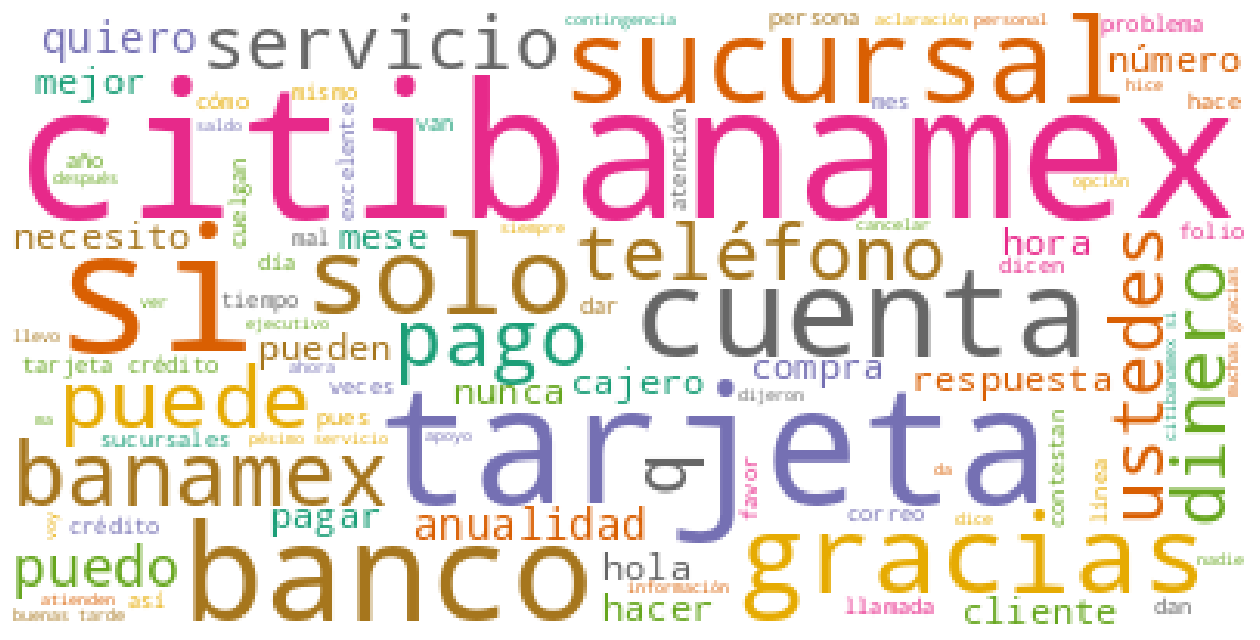

In [6]:
import wordcloud
from wordcloud import WordCloud

wc = WordCloud(
    max_words=100,
    background_color="white",
    colormap="Dark2",
    max_font_size=100,
    random_state=6
)

plt.figure(figsize=(16,9))
wc.generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [9]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to C:\Users\CESAR
[nltk_data]     QUEZADA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\CESAR
[nltk_data]     QUEZADA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\CESAR
[nltk_data]     QUEZADA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [11]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)
fdist = nltk.FreqDist(tokens)

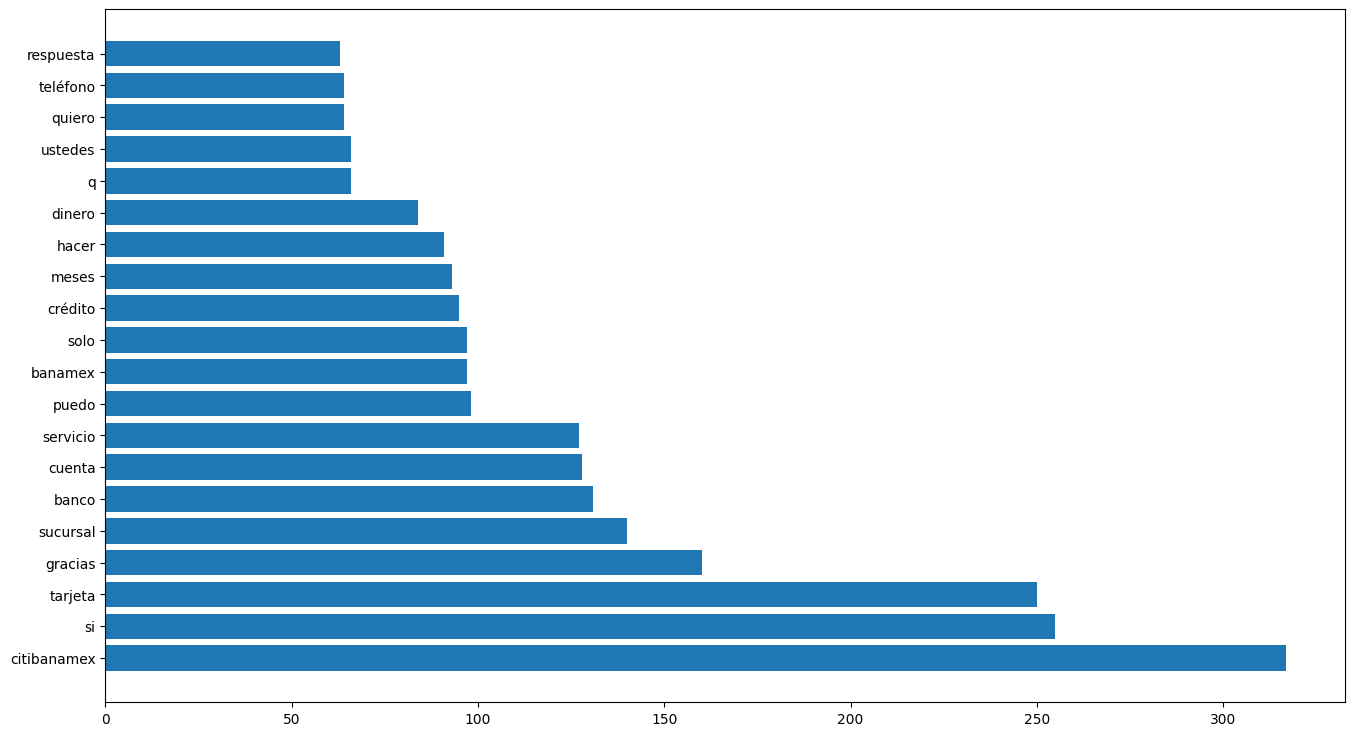

In [12]:
y = list(range(20))
top_words, counts = zip(*fdist.most_common(20))
plt.figure(figsize=(16, 9))
plt.barh(y, counts)
plt.yticks(y, top_words)
plt.show()

## Análisis de Similitud de Comentarios

Extraemos el campo "com" que contiene el comentario

In [15]:
comm = df["com_clean"][1:500]
comm.head()

1    pesimo servicio call center contestan voz floj...
2    mejor voy sucursal da confianza personas q con...
3    citibanamex podrían decirme dónde puedo llamar...
4    citibanamex gracias si gustaría saber vence pr...
5    tenho um problemas bloqueada tarjeta estou em ...
Name: com_clean, dtype: object

#### Creamos la Matriz Término-Documento (TDM) con CountVectorizer

In [20]:
import sys
sys.path.append("../src")
from similarity_analysis import (build_tdm)

In [21]:
tdm = build_tdm(comm)
tdm.head()

,1,2,3,4,5,6,7,8,9,10,...,490,491,492,493,494,495,496,497,498,499
00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
005717,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01q,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Calculamos la matriz de correlaciones

In [22]:
import sys
sys.path.append("../src")

from similarity_analysis import (compute_correlation_matrix)

In [23]:
matcor = compute_correlation_matrix(tdm)
matcor.head()

,1,2,3,4,5,6,7,8,9,10,...,490,491,492,493,494,495,496,497,498,499
1,1.000000,0.075478,-0.005174,-0.004985,-0.003907,-0.004584,-0.002760,0.067039,-0.002390,-0.002390,...,-0.006217,0.179006,-0.006192,0.050988,0.053087,-0.003654,0.112391,-0.004584,0.164775,-0.006949
2,0.075478,1.000000,-0.005387,0.072133,-0.004067,-0.004772,-0.002874,0.063978,-0.002488,-0.002488,...,0.043672,-0.004549,-0.006446,0.157992,0.050516,-0.003804,-0.006473,-0.004772,-0.002488,0.044662
3,-0.005174,-0.005387,1.000000,0.143662,-0.004221,-0.004953,-0.002983,0.061236,0.152244,0.152244,...,0.089941,0.080199,-0.006691,-0.006453,-0.006719,0.198929,-0.006719,0.076031,-0.002582,0.042509
4,-0.004985,0.072133,0.143662,1.000000,-0.004067,-0.004772,-0.002874,0.133717,0.158151,0.318790,...,0.194103,-0.004549,-0.006446,-0.006217,-0.006473,0.101443,-0.006473,0.163277,-0.002488,-0.007234
5,-0.003907,-0.004067,-0.004221,-0.004067,1.000000,-0.003740,-0.002252,-0.004515,-0.001950,-0.001950,...,-0.005072,-0.003565,-0.005052,0.064834,-0.005073,-0.002981,-0.005073,-0.003740,-0.001950,0.060419


#### Transformamos la matriz en un DataFrame de input para el Grafo

In [24]:
import sys
sys.path.append("../src")

from similarity_analysis import (build_edge_dataframe)

In [25]:
cordf = build_edge_dataframe(matcor, threshold=0.6)

cordf.sort_values("peso", ascending=False).head()

,inicio,fin,peso
53,51,301,1.0
39,49,51,1.0
42,49,246,1.0
44,49,301,1.0
45,49,305,1.0


Los tweets que tienen correlación 1, tienen exactamente el mismo contenido

In [26]:
comm[comm.index==51]

51    citibanamex gracias
Name: com_clean, dtype: object

In [27]:
comm[comm.index==301]

301    citibanamex gracias
Name: com_clean, dtype: object

#### Creamos el Grafo de Relaciones entre Comentarios, para identificar visualmente los que sean similares

In [31]:
import sys
sys.path.append("../src")

from similarity_analysis import (build_similarity_graph, get_top_nodes)

In [29]:
G = build_similarity_graph(cordf)

Guardar el grado de cada nodo en un diccionario

In [32]:
gdeg = G.degree()

get_top_nodes(dict(gdeg))

{12: 14,
 28: 14,
 49: 13,
 51: 13,
 129: 13,
 246: 13,
 301: 13,
 305: 13,
 402: 13,
 10: 11}

#### Visualizamos los Tweets, agrupados por similitud

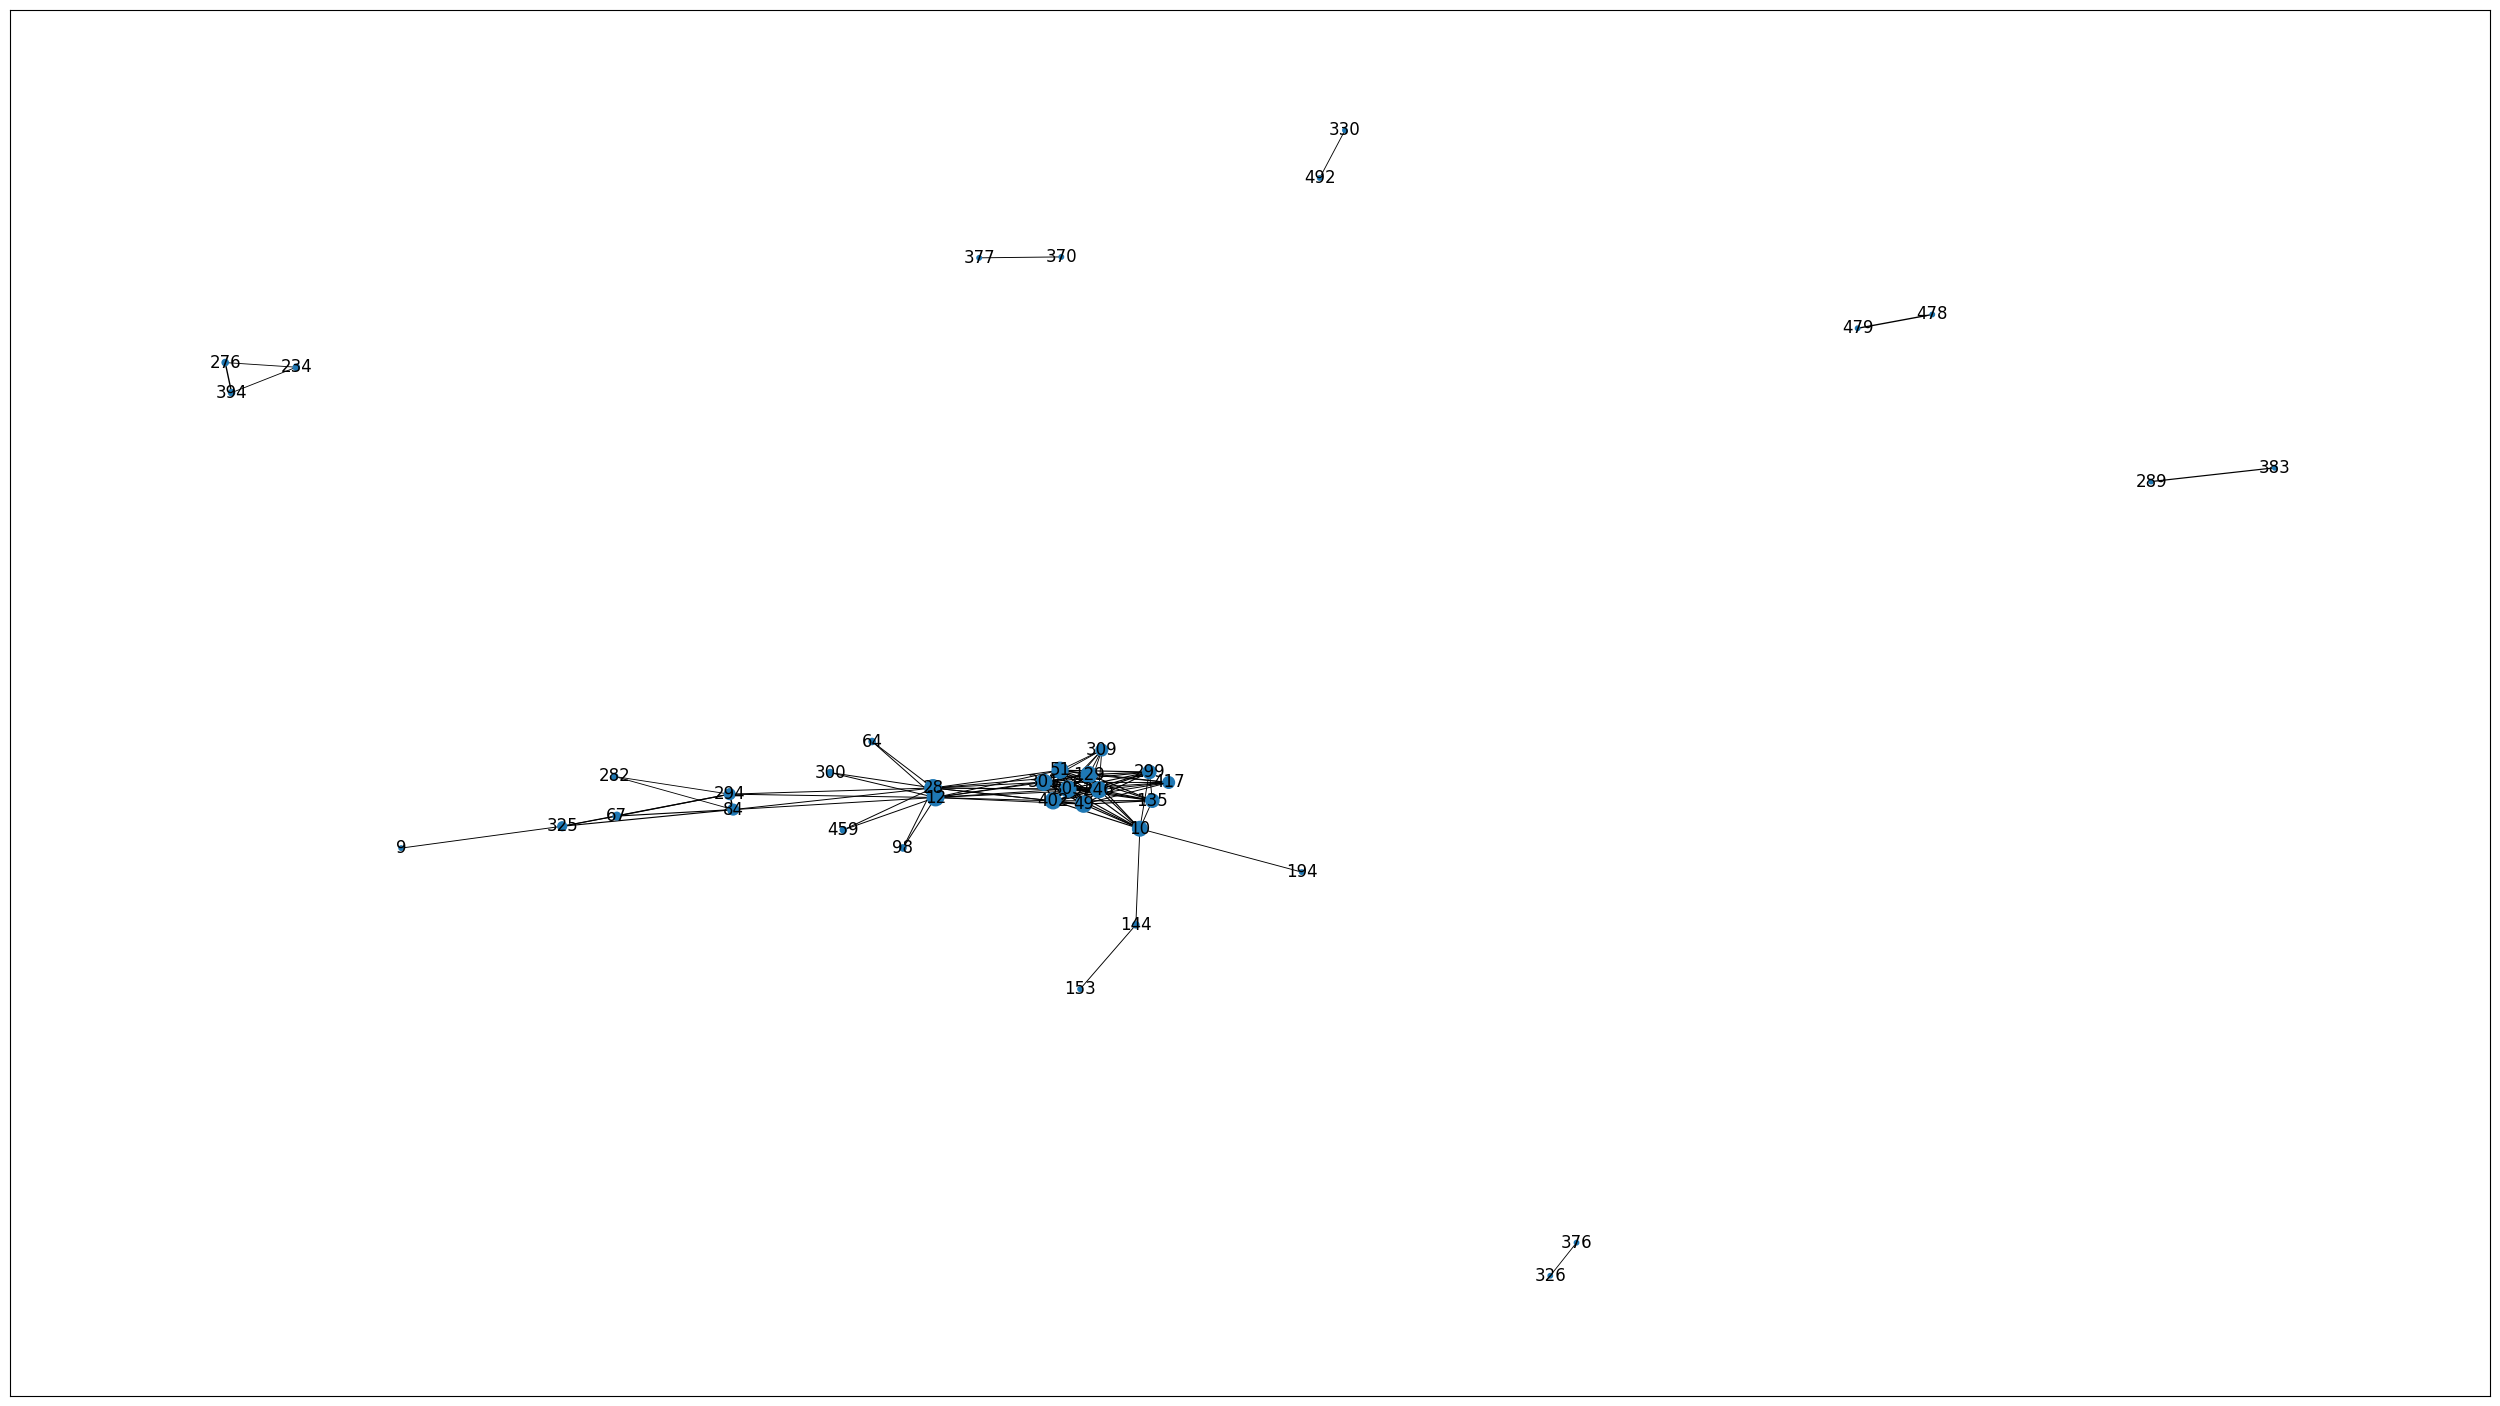

In [33]:
plt.figure(figsize=(32,18))

pos = nx.spring_layout(G)

edges = G.edges()
weights = [G[u][v]['peso'] for u,v in edges]

nx.draw_networkx(
    G,
    width=weights,
    pos=pos,
    node_size=[val*10 for (node,val) in gdeg]
)

plt.show()

## Topic Modeling: Descubriendo Temáticas en los Comentarios